In [30]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import operator

In [31]:
load_dotenv()

True

In [32]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

In [33]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10", ge=0, le=10)

In [34]:
parser = PydanticOutputParser(pydantic_object=EvaluationSchema)

In [35]:
essay = """
**The Importance of Reading Books**

Reading books is one of the most useful habits a person can develop. Books provide knowledge, improve language skills, and help people understand different ideas and perspectives. In today’s digital world, reading remains an important activity for personal growth.

One major benefit of reading is gaining knowledge. Books contain information about history, science, culture, and many other subjects. Reading regularly helps people learn new things and expand their understanding of the world.

Another advantage of reading is that it improves vocabulary and communication skills. People who read often become better at expressing their thoughts and writing clearly. Reading also increases concentration and imagination because readers create mental images while following a story or understanding concepts.

In conclusion, reading books is a valuable habit that supports education and personal development. Even spending a small amount of time reading each day can have a positive impact on a person’s life.
"""

In [36]:
prompt = f"""
evaluate the below essay \n {essay} \nReturn output in this format: {parser.get_format_instructions()}
"""

In [37]:
response = model.invoke(prompt)

result = parser.parse(response.content)
result

EvaluationSchema(feedback='The essay is well-structured and easy to understand. It highlights three key benefits of reading: gaining knowledge, improving language skills, and increasing concentration and imagination. The conclusion effectively summarizes the main points and emphasizes the value of reading in supporting education and personal development. However, the essay could be improved by: Providing more specific examples to support the claims made. Using more complex sentence structures to make the writing more engaging. Considering the opposing viewpoint to the importance of reading and addressing potential counterarguments.', score=8)

In [38]:
result.feedback

'The essay is well-structured and easy to understand. It highlights three key benefits of reading: gaining knowledge, improving language skills, and increasing concentration and imagination. The conclusion effectively summarizes the main points and emphasizes the value of reading in supporting education and personal development. However, the essay could be improved by: Providing more specific examples to support the claims made. Using more complex sentence structures to make the writing more engaging. Considering the opposing viewpoint to the importance of reading and addressing potential counterarguments.'

In [39]:
result.score

8

In [40]:
class essayState(TypedDict):
    essay : str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_scores : Annotated[list[int], operator.add]
    avg_score : float

In [56]:
def evaluate_language(state: essayState):
    prompt = f"Evalute the below essay on the basis of the language quality used :\n{state['essay']}\n\nreturn only valid JSON {parser.get_format_instructions()}"

    response = model.invoke(prompt)
    result = parser.parse(response.content)

    return {'language_feedback' : result.feedback, 'individual_scores' : [result.score]}
    

In [55]:
def evaluate_analysis(state: essayState):
    prompt = f"Evalute the below essay on the basis of the depht of anlaysis used :\n{state['essay']}\n\nreturn only valid JSON {parser.get_format_instructions()}"

    response = model.invoke(prompt)
    result = parser.parse(response.content)

    return {'analysis_feedback' : result.feedback, 'individual_scores' : [result.score]}
    

In [54]:
def evaluate_thought(state: essayState):
    prompt = f"Evalute the below essay on the basis of the calrity of thought used :\n{state['essay']}\n\nreturn only valid JSON {parser.get_format_instructions()}"

    response = model.invoke(prompt)
    result = parser.parse(response.content)

    return {'clarity_feedback' : result.feedback, 'individual_scores' : [result.score]}
    

In [49]:
def join_results(state: essayState):
    return {}

In [45]:
def final_evaluation(state : essayState):
    prompt = f"Based on the following feedback create a summarized feedback\nlanguage feedback : {state['language_feedback']} \ndepth of analysis feedback : {state['analysis_feedback']} \n clarity of thought feedback : {state['clarity_feedback']}"

    response = model.invoke(prompt)

    overall_feedback = response.content

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {"overall_feedback" : overall_feedback, "avg_score" : avg_score}

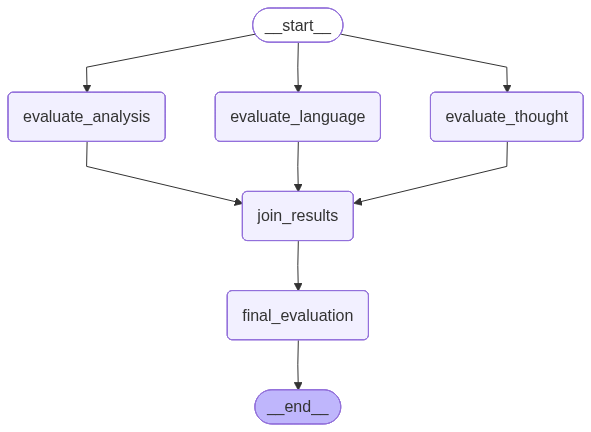

In [57]:
graph = StateGraph(essayState)

# add nodes
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("join_results", join_results)
graph.add_node("final_evaluation", final_evaluation)


# add edges
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_thought")

graph.add_edge("evaluate_language", "join_results")
graph.add_edge("evaluate_analysis", "join_results")
graph.add_edge("evaluate_thought", "join_results")

graph.add_edge("join_results", "final_evaluation")
graph.add_edge("final_evaluation", END)

# compile graph
workflow = graph.compile()

workflow

In [58]:
essay2 = """
**Why Failure Is Important for Success**

Success is often celebrated, but failure plays an equally important role in personal growth and achievement. Many people see failure as something negative, yet it provides opportunities to learn, improve, and develop resilience. Without experiencing setbacks, individuals may never fully understand how to overcome challenges or refine their abilities.

One reason failure is important is that it encourages learning. When people fail, they are forced to examine what went wrong and identify areas for improvement. For example, students who perform poorly on an exam often gain a better understanding of their weaknesses and adjust their study methods. This process leads to stronger long-term performance rather than temporary success.

Failure also builds resilience and perseverance. People who never face difficulties may struggle when unexpected obstacles arise. Experiencing failure teaches patience and develops the ability to continue working toward goals despite setbacks. Many successful entrepreneurs and inventors experienced repeated failures before achieving meaningful results.

However, failure only becomes valuable when people reflect on it and take action. Repeating the same mistakes without learning offers little benefit. Growth comes from analyzing experiences and making intentional improvements.

In conclusion, failure should not be viewed as the opposite of success but as an essential part of achieving it. By encouraging learning, building resilience, and promoting self-improvement, failure becomes an important step toward long-term success.
"""

In [59]:
essay3 = """
**Why Mobile Phones Are Good**

Mobile phones are good because many people use them every day. Phones help people and people like phones. They are important in modern life and everyone should have one because phones are useful.

Phones can call people and send messages. They also have games and internet. Many students use phones and many workers also use phones. This shows phones are popular.

Another reason phones are good is because they help people do many things. People can watch videos and talk to friends. Phones are useful and easy.

In conclusion, mobile phones are good because they help people and are important. Phones are very useful and people use them every day.
"""

In [62]:
initial_state = {"essay" : essay3}

final_state = workflow.invoke(initial_state)

final_state

{'essay': '\n**Why Mobile Phones Are Good**\n\nMobile phones are good because many people use them every day. Phones help people and people like phones. They are important in modern life and everyone should have one because phones are useful.\n\nPhones can call people and send messages. They also have games and internet. Many students use phones and many workers also use phones. This shows phones are popular.\n\nAnother reason phones are good is because they help people do many things. People can watch videos and talk to friends. Phones are useful and easy.\n\nIn conclusion, mobile phones are good because they help people and are important. Phones are very useful and people use them every day.\n',
 'language_feedback': "The language used in the essay is simple and lacks sophistication. The sentence structure is basic and repetitive, making it hard to follow. The essay could benefit from more complex vocabulary, varied sentence structure, and supporting evidence to strengthen its argume

In [63]:
print(final_state['overall_feedback'])

Here's a summarized feedback:

**Main Issues:**

1. **Language and Sentence Structure:** The language is simple and lacks sophistication. The sentence structure is basic and repetitive, making the essay hard to follow.
2. **Depth of Analysis:** The essay presents a simplistic and surface-level argument, lacking depth and exploration of complexities.
3. **Clarity of Thought:** The ideas presented are vague and lack depth, with a lack of strong supporting evidence and a disjointed structure.

**Specific Recommendations:**

1. Use more complex vocabulary and varied sentence structure to enhance clarity.
2. Provide concrete evidence and details to support arguments.
3. Specify what is meant by "useful" and "important" to enhance clarity.
4. Develop a more nuanced and in-depth analysis of the topic.
5. Improve the structure of the essay, including a clear introduction, body, and conclusion.
